In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported!")

✅ Libraries imported!


In [3]:
df = pd.read_csv('cleaned_data.csv')

print("✅ Data loaded!")
print(f"Shape: {df.shape}")
print(f"\nFirst 3 rows:")
print(df.head(3))

✅ Data loaded!
Shape: (44621, 3)

First 3 rows:
                                          clean_text  label  word_count
0  ben stein call th circuit court committed coup...      0         109
1  trump drop steve bannon national security coun...      1         472
2  puerto rico expects u lift jones act shipping ...      1         182


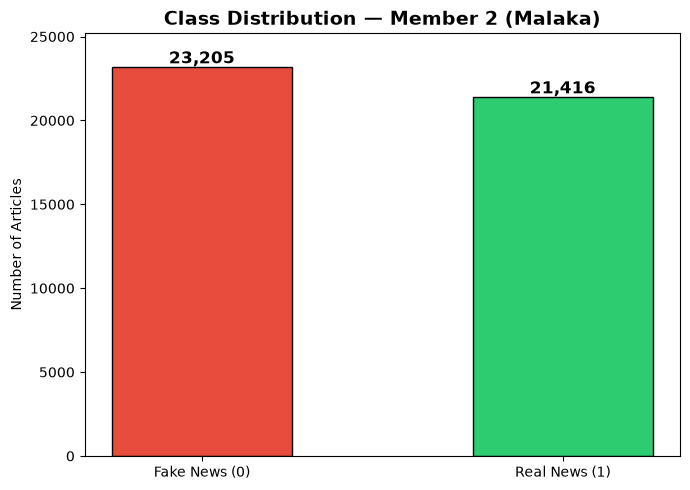


Fake News : 23,205
Real News : 21,416
Ratio     : 1.08


In [4]:
class_counts = df['label'].value_counts()

plt.figure(figsize=(7, 5))
bars = plt.bar(
    ['Fake News (0)', 'Real News (1)'],
    class_counts.values,
    color=['#e74c3c', '#2ecc71'],
    edgecolor='black', width=0.5)

for bar, count in zip(bars, class_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 200,
             f'{count:,}', ha='center',
             fontsize=12, fontweight='bold')

plt.title('Class Distribution — Member 2 (Malaka)',
          fontsize=14, fontweight='bold')
plt.ylabel('Number of Articles')
plt.ylim(0, max(class_counts.values) + 2000)
plt.tight_layout()
plt.savefig('m2_eda_class_distribution.png', dpi=150)
plt.show()

print(f"\nFake News : {class_counts[0]:,}")
print(f"Real News : {class_counts[1]:,}")
print(f"Ratio     : {class_counts[0]/class_counts[1]:.2f}")

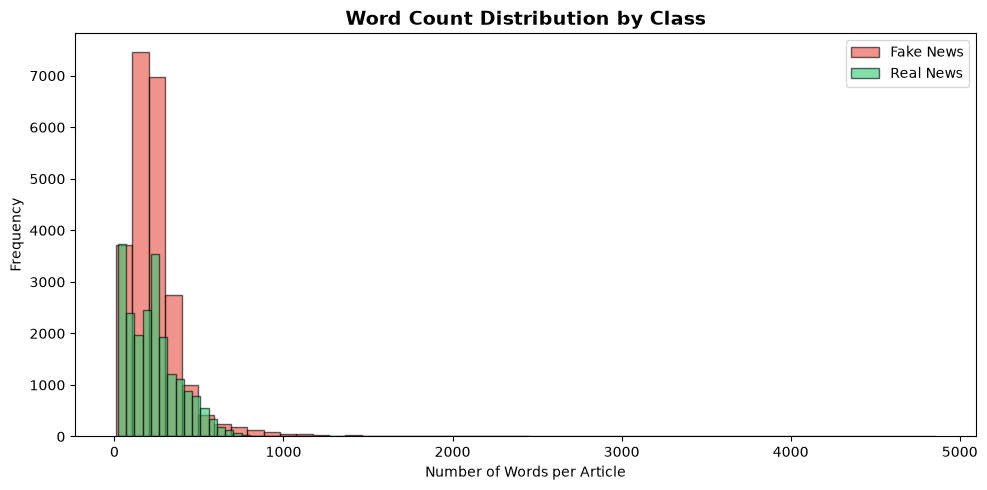

=== Word Count Statistics ===

Fake News:
count    23205.0
mean       243.9
std        229.9
min         10.0
25%        146.0
50%        207.0
75%        285.0
max       4854.0
Name: word_count, dtype: float64

Real News:
count    21416.0
mean       234.6
std        159.0
min         21.0
25%         95.0
50%        219.0
75%        314.0
max       2460.0
Name: word_count, dtype: float64


In [5]:
fake_df = df[df['label'] == 0]
real_df = df[df['label'] == 1]

plt.figure(figsize=(10, 5))
plt.hist(fake_df['word_count'], bins=50,
         alpha=0.6, color='#e74c3c',
         label='Fake News', edgecolor='black')
plt.hist(real_df['word_count'], bins=50,
         alpha=0.6, color='#2ecc71',
         label='Real News', edgecolor='black')

plt.title('Word Count Distribution by Class',
          fontsize=14, fontweight='bold')
plt.xlabel('Number of Words per Article')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.savefig('m2_word_count_distribution.png', dpi=150)
plt.show()

print("=== Word Count Statistics ===")
print(f"\nFake News:")
print(fake_df['word_count'].describe().round(1))
print(f"\nReal News:")
print(real_df['word_count'].describe().round(1))



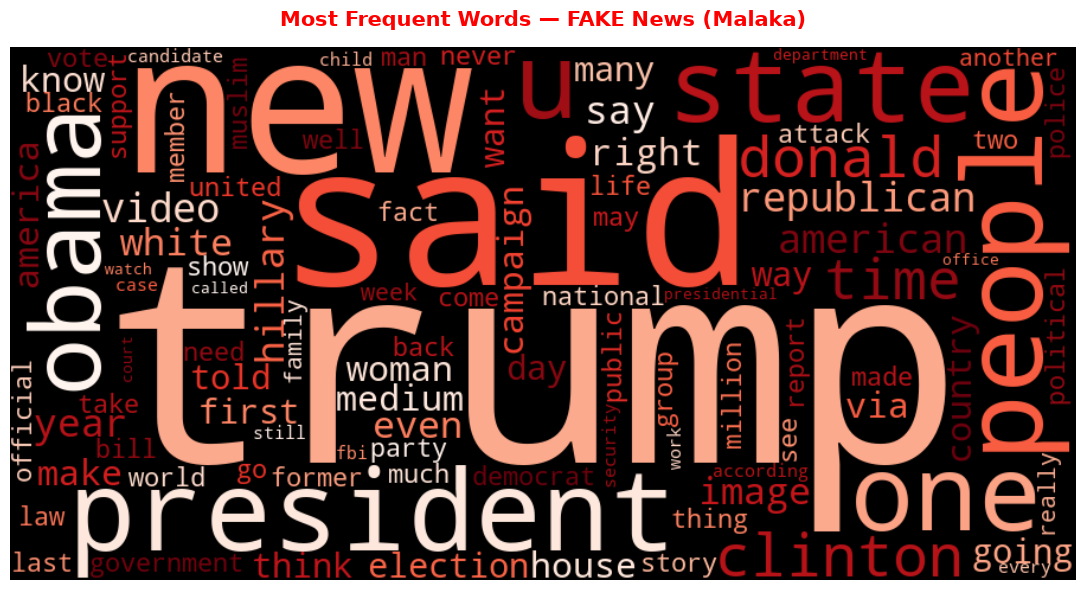

✅ Fake news word cloud saved!


In [6]:
fake_text = ' '.join(fake_df['clean_text'].astype(str))

wc = WordCloud(
    width=900, height=450,
    background_color='black',
    colormap='Reds',
    max_words=100,
    collocations=False
).generate(fake_text)

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words — FAKE News (Malaka)',
          fontsize=15, fontweight='bold',
          color='red', pad=15)
plt.tight_layout()
plt.savefig('m2_wordcloud_fake.png', dpi=150)
plt.show()

print("✅ Fake news word cloud saved!")

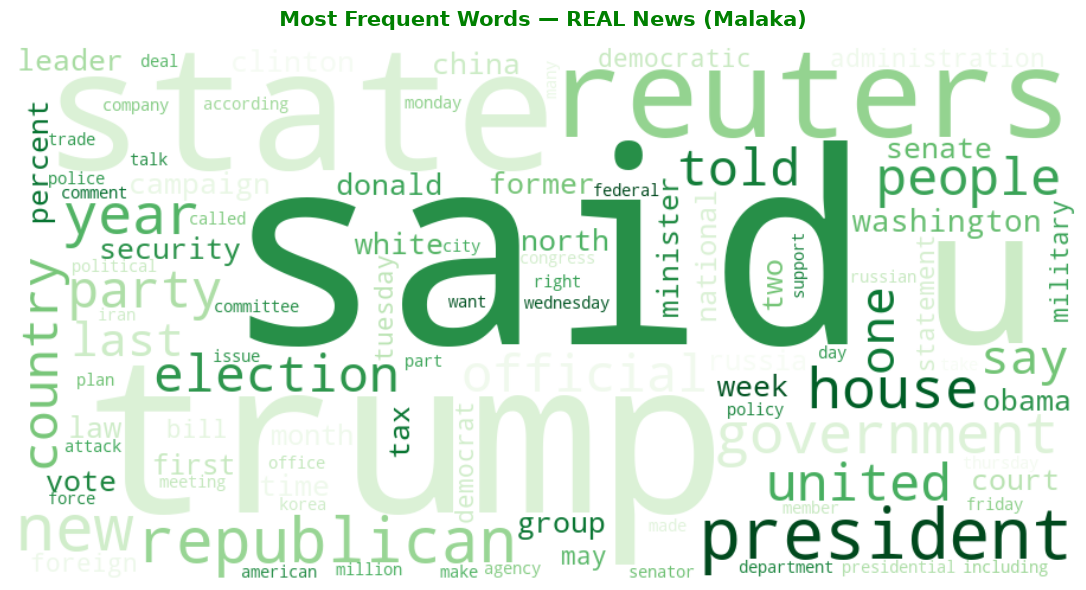

✅ Real news word cloud saved!


In [7]:
real_text = ' '.join(real_df['clean_text'].astype(str))

wc2 = WordCloud(
    width=900, height=450,
    background_color='white',
    colormap='Greens',
    max_words=100,
    collocations=False
).generate(real_text)

plt.figure(figsize=(12, 6))
plt.imshow(wc2, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words — REAL News (Malaka)',
          fontsize=15, fontweight='bold',
          color='green', pad=15)
plt.tight_layout()
plt.savefig('m2_wordcloud_real.png', dpi=150)
plt.show()

print("✅ Real news word cloud saved!")

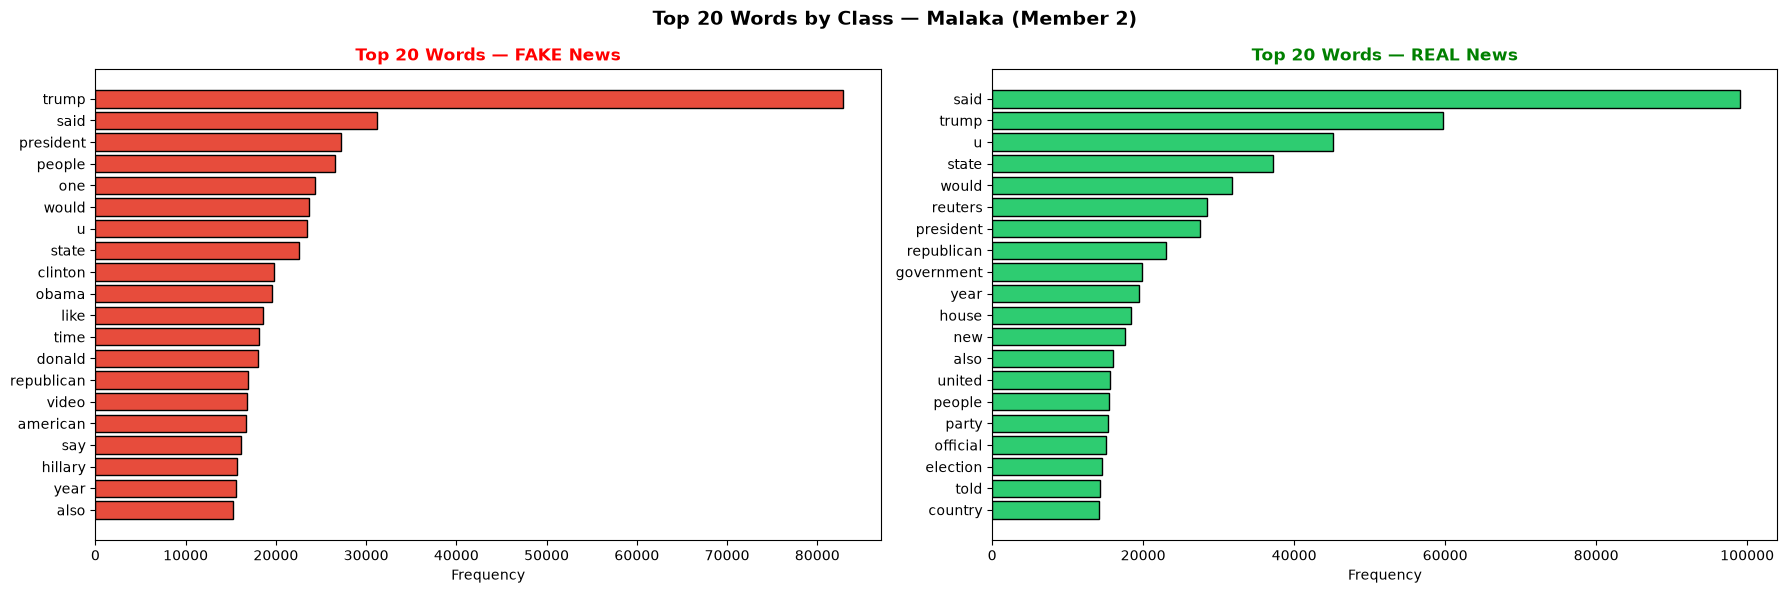

✅ Top words chart saved!


In [8]:
def get_top_words(series, n=20):
    words = ' '.join(series.astype(str)).split()
    return Counter(words).most_common(n)

fake_top = get_top_words(fake_df['clean_text'])
real_top = get_top_words(real_df['clean_text'])

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

fw, fc = zip(*fake_top)
axes[0].barh(list(fw)[::-1], list(fc)[::-1],
             color='#e74c3c', edgecolor='black')
axes[0].set_title('Top 20 Words — FAKE News',
    fontsize=12, fontweight='bold', color='red')
axes[0].set_xlabel('Frequency')

rw, rc = zip(*real_top)
axes[1].barh(list(rw)[::-1], list(rc)[::-1],
             color='#2ecc71', edgecolor='black')
axes[1].set_title('Top 20 Words — REAL News',
    fontsize=12, fontweight='bold', color='green')
axes[1].set_xlabel('Frequency')

plt.suptitle('Top 20 Words by Class — Malaka (Member 2)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('m2_top_words_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("✅ Top words chart saved!")

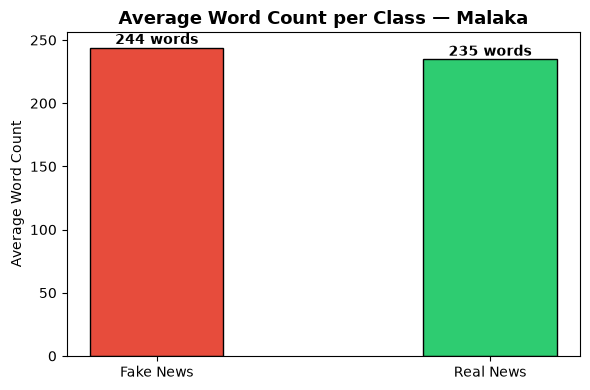

In [9]:
avg_words = df.groupby('label')['word_count'].mean()

plt.figure(figsize=(6, 4))
bars = plt.bar(
    ['Fake News', 'Real News'],
    avg_words.values,
    color=['#e74c3c', '#2ecc71'],
    edgecolor='black', width=0.4)

for bar, val in zip(bars, avg_words.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 3,
             f'{val:.0f} words',
             ha='center', fontweight='bold')

plt.title('Average Word Count per Class — Malaka',
          fontsize=13, fontweight='bold')
plt.ylabel('Average Word Count')
plt.tight_layout()
plt.savefig('m2_avg_word_count.png', dpi=150)
plt.show()

In [10]:
print("=" * 55)
print("    EDA SUMMARY — MALAKA (Member 2)")
print("=" * 55)
print(f"""
📊 DATASET OVERVIEW
   Total Articles   : {len(df):,}
   Fake Articles    : {len(fake_df):,}
   Real Articles    : {len(real_df):,}
   Class Ratio      : {len(fake_df)/len(real_df):.2f}

📝 TEXT LENGTH INSIGHTS
   Avg words (Fake) : {fake_df['word_count'].mean():.0f} words
   Avg words (Real) : {real_df['word_count'].mean():.0f} words
   Max words        : {df['word_count'].max()} words
   Min words        : {df['word_count'].min()} words

🔍 KEY OBSERVATIONS
   1. Dataset is fairly balanced
   2. Fake news uses more emotional language
   3. Real news uses more formal/political terms
   4. Bag of Words will capture word frequencies
   5. Class distribution suitable for classification

📁 CHARTS SAVED
   ✅ m2_eda_class_distribution.png
   ✅ m2_word_count_distribution.png
   ✅ m2_wordcloud_fake.png
   ✅ m2_wordcloud_real.png
   ✅ m2_top_words_comparison.png
   ✅ m2_avg_word_count.png
""")

    EDA SUMMARY — MALAKA (Member 2)

📊 DATASET OVERVIEW
   Total Articles   : 44,621
   Fake Articles    : 23,205
   Real Articles    : 21,416
   Class Ratio      : 1.08

📝 TEXT LENGTH INSIGHTS
   Avg words (Fake) : 244 words
   Avg words (Real) : 235 words
   Max words        : 4854 words
   Min words        : 10 words

🔍 KEY OBSERVATIONS
   1. Dataset is fairly balanced
   2. Fake news uses more emotional language
   3. Real news uses more formal/political terms
   4. Bag of Words will capture word frequencies
   5. Class distribution suitable for classification

📁 CHARTS SAVED
   ✅ m2_eda_class_distribution.png
   ✅ m2_word_count_distribution.png
   ✅ m2_wordcloud_fake.png
   ✅ m2_wordcloud_real.png
   ✅ m2_top_words_comparison.png
   ✅ m2_avg_word_count.png

